# 1. Install libraries

In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn imblearn torch

# 2. Library Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from time import time

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Classification algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Metrics

from sklearn.metrics import f1_score, accuracy_score, make_scorer#warnings.filterwarnings('ignore')

from imblearn.metrics import geometric_mean_score

from sklearn.preprocessing import RobustScaler

import random

# 3. Dataset Import

In [3]:

# Loading the Breast Cancer dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print("Dataset shape:", X.shape)
print("\nTarget distribution:")
print(y.value_counts())
print("\nTarget class names:", data.target_names)

Dataset shape: (569, 30)

Target distribution:
target
1    357
0    212
Name: count, dtype: int64

Target class names: ['malignant' 'benign']


In [4]:
X

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [5]:
y

0      0
1      0
2      0
3      0
4      0
      ..
564    0
565    0
566    0
567    0
568    1
Name: target, Length: 569, dtype: int64

# 4. Data preprocessing

In [6]:
# Check for missing values
print("Missing values:", X.isnull().sum().sum())

Missing values: 0


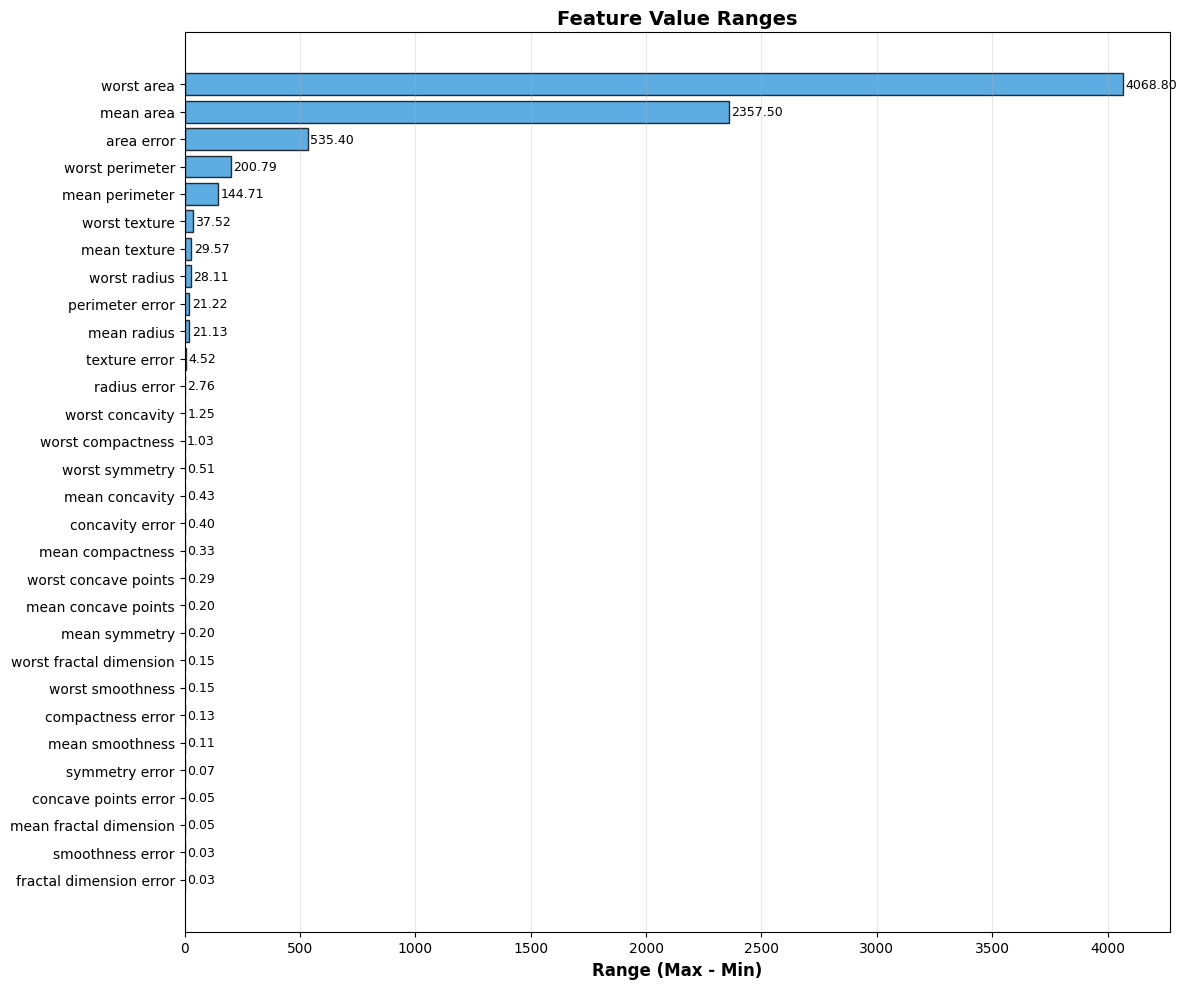

In [7]:
# Check feature scaling

# Calculate min and max for each feature
feature_ranges = pd.DataFrame({
    'Feature': X.columns,
    'Min': X.min().values,
    'Max': X.max().values,
    'Range': (X.max() - X.min()).values
})

# Sort by range in descending order
feature_ranges = feature_ranges.sort_values('Range', ascending=True)

# Create barplot
fig, ax = plt.subplots(figsize=(12, 10))

y_pos = np.arange(len(feature_ranges))
ax.barh(y_pos, feature_ranges['Range'], color='#3498db', alpha=0.8, edgecolor='black')

ax.set_yticks(y_pos)
ax.set_yticklabels(feature_ranges['Feature'])
ax.set_xlabel('Range (Max - Min)', fontsize=12, fontweight='bold')
ax.set_title('Feature Value Ranges', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, (idx, row) in enumerate(feature_ranges.iterrows()):
    ax.text(row['Range'] + 10, i, f"{row['Range']:.2f}", va='center', fontsize=9)

plt.tight_layout()
#plt.savefig('feature_ranges.png', dpi=150, bbox_inches='tight')
plt.show()

#print("Feature Range Analysis:")
#print(feature_ranges.to_string(index=False))

We will need to apply feature scaling from within the 5-fold CV loop.

# 5. Model Training with 5-Fold Cross Validation


In [8]:
# Define classifiers to test
classifiers = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVC': SVC(random_state=42),
    'KNN': KNeighborsClassifier(),
}

# Import RobustScaler
from sklearn.preprocessing import RobustScaler

# 5-Fold Stratified Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store results for all classifiers
all_results = []
all_feature_importances = {}  # Store feature importances for all models

for clf_name, clf in classifiers.items():
    print(f"Running 5-Fold Cross Validation with {clf_name}...\n")

    # Store results for each fold
    accuracies = []
    f1_scores = []
    gmeans = []
    train_times = []
    test_times = []
    feature_importances_list = []

    for fold_num, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Apply RobustScaler to training data
        scaler = RobustScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        if clf_name == 'Simple NN':
            model = SimpleNeuralNetwork(X_train_scaled.shape[1])
            criterion = nn.BCELoss()
            optimizer = optim.Adam(model.parameters(), lr=0.001)
            
            X_train_tensor = torch.FloatTensor(X_train_scaled)
            y_train_tensor = torch.FloatTensor(y_train.values).reshape(-1, 1)
            X_test_tensor = torch.FloatTensor(X_test_scaled)

            start_time = time()
            for epoch in range(50): # Small number of epochs to keep it fast
                model.train()
                optimizer.zero_grad()
                outputs = model(X_train_tensor)
                loss = criterion(outputs, y_train_tensor)
                loss.backward()
                optimizer.step()
            train_time = time() - start_time

            start_time = time()
            model.eval()
            with torch.no_grad():
                y_pred_tensor = model(X_test_tensor)
                y_pred = (y_pred_tensor.numpy() > 0.5).astype(int)
            test_time = time() - start_time
        else:
            # Train and evaluate
            start_time = time()
            clf.fit(X_train_scaled, y_train)
            train_time = time() - start_time

            # Store feature importances for tree-based models
            if hasattr(clf, 'feature_importances_'):
                feature_importances_list.append(clf.feature_importances_)

            start_time = time()
            y_pred = clf.predict(X_test_scaled)
            test_time = time() - start_time

        # Calculate metrics
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        gmean = geometric_mean_score(y_test, y_pred, average='weighted')

        accuracies.append(acc)
        f1_scores.append(f1)
        gmeans.append(gmean)
        train_times.append(train_time)
        test_times.append(test_time)

    # Store results in dictionary
    results = {
        'Classifier': clf_name,
        'Accuracy (mean)': np.mean(accuracies),
        'Accuracy (std)': np.std(accuracies),
        'F1-Score (mean)': np.mean(f1_scores),
        'F1-Score (std)': np.std(f1_scores),
        'G-Mean (mean)': np.mean(gmeans),
        'G-Mean (std)': np.std(gmeans),
        'Train Time (s)': np.mean(train_times),
        'Test Time (s)': np.mean(test_times)
    }
    all_results.append(results)

    print("=" * 60)
    print(f"{clf_name} - CROSS-VALIDATION SUMMARY")
    print("=" * 60)
    print(f"Accuracy: {np.mean(accuracies):.4f} (+/- {np.std(accuracies):.4f})")
    print(f"F1-Score: {np.mean(f1_scores):.4f} (+/- {np.std(f1_scores):.4f})")
    print(f"G-Mean:   {np.mean(gmeans):.4f} (+/- {np.std(gmeans):.4f})")
    print(f"Avg Train Time: {np.mean(train_times):.6f}s")
    print(f"Avg Test Time:  {np.mean(test_times):.6f}s")
    
    # Store feature importances for this classifier if available
    if feature_importances_list:
        mean_feature_importances = np.mean(feature_importances_list, axis=0)
        std_feature_importances = np.std(feature_importances_list, axis=0)
        all_feature_importances[clf_name] = {
            'mean': mean_feature_importances,
            'std': std_feature_importances
        }

# Create feature importance dataframes for all tree-based models
feature_importance_dfs = {}
for clf_name, importances in all_feature_importances.items():
    feature_importance_dfs[clf_name] = pd.DataFrame({
        'Feature': X.columns,
        'Mean Importance': importances['mean'],
        'Std Importance': importances['std']
    }).sort_values('Mean Importance', ascending=False)

# Create results dataframe
results_df = pd.DataFrame(all_results)


print("=" * 100)
print("=" * 100)
print("=" * 100)
print(results_df.to_string(index=False))
print("COMPARISON OF ALL CLASSIFIERS")
print("=" * 100)


Running 5-Fold Cross Validation with Random Forest...

Random Forest - CROSS-VALIDATION SUMMARY
Accuracy: 0.9561 (+/- 0.0123)
F1-Score: 0.9560 (+/- 0.0125)
G-Mean:   0.9526 (+/- 0.0170)
Avg Train Time: 0.096270s
Avg Test Time:  0.003890s
Running 5-Fold Cross Validation with Logistic Regression...

Logistic Regression - CROSS-VALIDATION SUMMARY
Accuracy: 0.9789 (+/- 0.0131)
F1-Score: 0.9788 (+/- 0.0133)
G-Mean:   0.9737 (+/- 0.0187)
Avg Train Time: 0.005571s
Avg Test Time:  0.000221s
Running 5-Fold Cross Validation with SVC...

SVC - CROSS-VALIDATION SUMMARY
Accuracy: 0.9737 (+/- 0.0235)
F1-Score: 0.9735 (+/- 0.0237)
G-Mean:   0.9694 (+/- 0.0271)
Avg Train Time: 0.004353s
Avg Test Time:  0.001102s
Running 5-Fold Cross Validation with KNN...

KNN - CROSS-VALIDATION SUMMARY
Accuracy: 0.9596 (+/- 0.0163)
F1-Score: 0.9592 (+/- 0.0166)
G-Mean:   0.9505 (+/- 0.0230)
Avg Train Time: 0.001024s
Avg Test Time:  0.008654s
         Classifier  Accuracy (mean)  Accuracy (std)  F1-Score (mean)  F1-Sc

In [9]:
# Display feature importances for all models that have them

for clf_name, df in feature_importance_dfs.items():    
    display(df)

,Feature,Mean Importance,Std Importance
23,worst area,0.158870,0.019779
27,worst concave points,0.124576,0.006955
7,mean concave points,0.095846,0.020713
22,worst perimeter,0.090661,0.012187
2,mean perimeter,0.076249,0.010363
20,worst radius,0.071512,0.005836
6,mean concavity,0.058122,0.013637
3,mean area,0.050413,0.008376
0,mean radius,0.044680,0.007172
13,area error,0.034147,0.005583


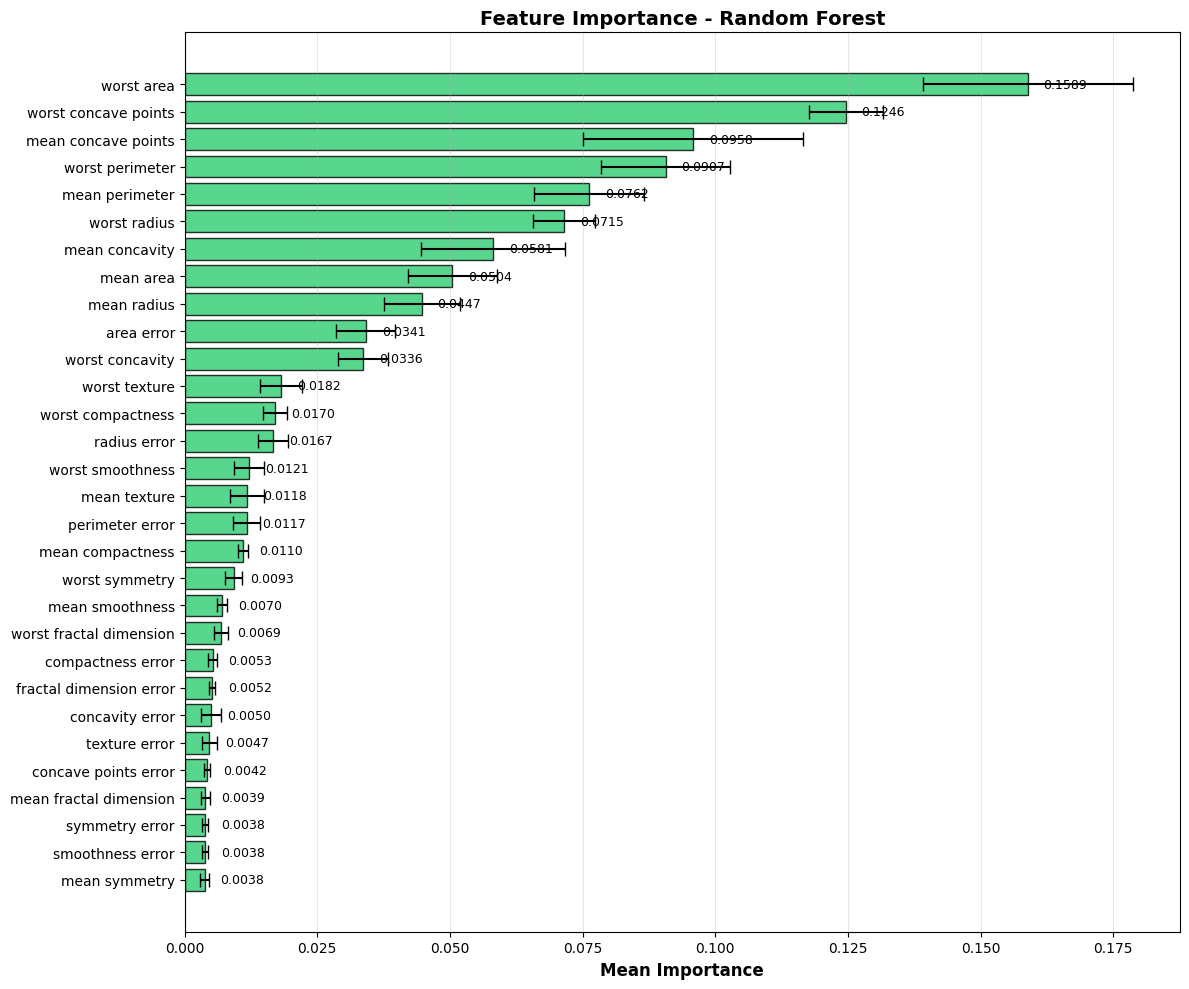

In [10]:
# Plot feature importances for all models that have them
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6']

for idx, (clf_name, df) in enumerate(feature_importance_dfs.items()):
    fig, ax = plt.subplots(figsize=(12, 10))
    
    y_pos = np.arange(len(df))
    color = colors[idx % len(colors)]
    
    ax.barh(y_pos, df['Mean Importance'],
        xerr=df['Std Importance'],
        color=color, alpha=0.8, edgecolor='black', capsize=5)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df['Feature'])
    ax.set_xlabel('Mean Importance', fontsize=12, fontweight='bold')
    ax.set_title(f'Feature Importance - {clf_name}', fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.invert_yaxis()
    
    # Add value labels on bars
    for i, (_, row) in enumerate(df.iterrows()):
        ax.text(row['Mean Importance'] + 0.003, i, f"{row['Mean Importance']:.4f}",
            va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    #plt.savefig(f'feature_importance_{clf_name.replace(" ", "_")}.png', dpi=150, bbox_inches='tight')


# 6. Using a Neural Network to get a better F1-Score

 ## 6.1 Creating Testing General Neural Network model and training logic

In [11]:
class NeuralNetwork(nn.Module):
    def __init__(self, input_dim, dropout_rate=0.3):
        super(NeuralNetwork, self).__init__()
        
        # First layer
        self.fc1 = nn.Linear(input_dim, 32)
        self.bn1 = nn.BatchNorm1d(32)
        self.dropout1 = nn.Dropout(dropout_rate)
        
        # Output layer
        self.fc2 = nn.Linear(32, 1)
        
    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = torch.relu(x)
        x = self.dropout1(x)
        
        x = self.fc2(x)
        x = torch.sigmoid(x)
        
        return x

def build_model(input_dim, l2_reg=0.01, dropout_rate=0.3, learning_rate=0.0001):
    model = NeuralNetwork(input_dim, dropout_rate)
    criterion = nn.BCELoss()
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=l2_reg)
    
    return model, optimizer, criterion


def train_and_evaluate_model(X_train, y_train, X_test, y_test, params):
    """
    Trains and evaluates the neural network for a single fold.
    """
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Split training data for validation
    val_split = int(0.8 * len(X_train_scaled))
    X_train_fold, X_val_fold = X_train_scaled[:val_split], X_train_scaled[val_split:]
    y_train_fold, y_val_fold = y_train.values[:val_split], y_train.values[val_split:]

    # Convert to PyTorch tensors
    X_train_tensor = torch.FloatTensor(X_train_fold)
    y_train_tensor = torch.FloatTensor(y_train_fold).reshape(-1, 1)
    X_val_tensor = torch.FloatTensor(X_val_fold)
    y_val_tensor = torch.FloatTensor(y_val_fold).reshape(-1, 1)
    X_test_tensor = torch.FloatTensor(X_test_scaled)
    X_train_full_tensor = torch.FloatTensor(X_train_scaled)
    
    # Create data loaders with fixed generator for reproducibility
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    generator = torch.Generator()
    generator.manual_seed(42)
    train_loader = DataLoader(
        train_dataset, 
        batch_size=params['batch_size'], 
        shuffle=params.get('shuffle', True),
        generator=generator if params.get('shuffle', True) else None
    )

    model, optimizer, criterion = build_model(
        input_dim=X_train_scaled.shape[1],
        l2_reg=params['l2_reg'],
        dropout_rate=params['dropout_rate'],
        learning_rate=params['learning_rate']
    )

    # Training loop with early stopping
    best_val_acc = 0
    patience_counter = 0
    patience = 10
    best_model_state = None
    
    start_time = time()
    for epoch in range(50):
        model.train()
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
        
        # Validation
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_tensor)
            val_preds = (val_outputs > 0.5).float()
            val_acc = (val_preds == y_val_tensor).float().mean().item()
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1
        
        if patience_counter >= patience:
            break
    
    train_time = time() - start_time
    
    # Restore best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    # Evaluate
    model.eval()
    with torch.no_grad():
        y_train_pred_proba = model(X_train_full_tensor).numpy()
        y_train_pred = (y_train_pred_proba > 0.5).astype(int).flatten()
        train_acc = accuracy_score(y_train, y_train_pred)

        # Test prediction with timing
        start_time = time()
        y_pred_proba = model(X_test_tensor).numpy()
        y_pred = (y_pred_proba > 0.5).astype(int).flatten()
        test_time = time() - start_time

        test_acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        gmean = geometric_mean_score(y_test, y_pred, average='weighted')

    return {
        'train_acc': train_acc,
        'test_acc': test_acc,
        'f1': f1,
        'gmean': gmean,
        'train_time': train_time,
        'test_time': test_time
    }

In [12]:


def run_cross_validation(X, y, cv, params):
    """
    Run k-fold cross-validation with given parameters.
    
    Args:
        X: Feature dataframe
        y: Target series
        cv: Cross-validation splitter
        params: Dictionary of hyperparameters
        
    Returns:
        Dictionary containing mean and std of metrics across folds
    """
    fold_train_accs = []
    fold_test_accs = []
    fold_f1s = []
    fold_gmeans = []
    fold_train_times = []
    fold_test_times = []

    for fold_num, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        results = train_and_evaluate_model(X_train, y_train, X_test, y_test, params)
        
        fold_train_accs.append(results['train_acc'])
        fold_test_accs.append(results['test_acc'])
        fold_f1s.append(results['f1'])
        fold_gmeans.append(results['gmean'])
        fold_train_times.append(results['train_time'])
        fold_test_times.append(results['test_time'])

    return {
        'mean_train_acc': np.mean(fold_train_accs),
        'std_train_acc': np.std(fold_train_accs),
        'mean_test_acc': np.mean(fold_test_accs),
        'std_test_acc': np.std(fold_test_accs),
        'mean_f1': np.mean(fold_f1s),
        'std_f1': np.std(fold_f1s),
        'mean_gmean': np.mean(fold_gmeans),
        'std_gmean': np.std(fold_gmeans),
        'mean_train_time': np.mean(fold_train_times),
        'mean_test_time': np.mean(fold_test_times),
        'overfitting_gap': np.mean(fold_train_accs) - np.mean(fold_test_accs)
    }

## 6.2 Tunning NN Model with Grid Search for better generalization

In [13]:
optimized_param_grid = {
    'l2_reg': [0.001, 0.005, 0.01, 0.05],
    'dropout_rate': [0.2, 0.3, 0.4, 0.5],
    'learning_rate': [0.0001, 0.0005, 0.001, 0.005],
    'batch_size': [8, 16, 32]
}

optimized_results = []

print("Starting hyperparameter grid search...")
print(f"Testing {len(optimized_param_grid['l2_reg']) * len(optimized_param_grid['dropout_rate']) * len(optimized_param_grid['learning_rate']) * len(optimized_param_grid['batch_size'])} configurations\n")

config_num = 1
for l2_reg in optimized_param_grid['l2_reg']:
    for dropout_rate in optimized_param_grid['dropout_rate']:
        for learning_rate in optimized_param_grid['learning_rate']:
            for batch_size in optimized_param_grid['batch_size']:
                print(f"Config {config_num}: L2={l2_reg}, Dropout={dropout_rate}, LR={learning_rate}, Batch={batch_size}")

                # Reset random seeds for fair comparison across configurations
                random.seed(42)
                np.random.seed(42)
                torch.manual_seed(42)
                if torch.cuda.is_available():
                    torch.cuda.manual_seed_all(42)

                params = {
                    'l2_reg': l2_reg,
                    'dropout_rate': dropout_rate,
                    'learning_rate': learning_rate,
                    'batch_size': batch_size,
                    'shuffle': True
                }

                # Run cross-validation
                cv_results = run_cross_validation(X, y, cv, params)

                optimized_results.append({
                    'Config': config_num,
                    'L2': l2_reg,
                    'Dropout': dropout_rate,
                    'LR': learning_rate,
                    'Batch': batch_size,
                    'Train Acc': cv_results['mean_train_acc'],
                    'Test Acc': cv_results['mean_test_acc'],
                    'F1-Score': cv_results['mean_f1'],
                    'G-Mean': cv_results['mean_gmean'],
                    'Gap': cv_results['overfitting_gap']
                })
                
                print(f"  Train: {cv_results['mean_train_acc']:.4f} | Test: {cv_results['mean_test_acc']:.4f} | F1: {cv_results['mean_f1']:.4f} | Gap: {cv_results['overfitting_gap']:.4f}")
                config_num += 1

optimized_df = pd.DataFrame(optimized_results)

print("\n" + "=" * 100)
print("OPTIMIZED TUNING RESULTS")
print("=" * 100)
print(optimized_df.sort_values('Test Acc', ascending=False).head(10).to_string(index=False))
print("=" * 100)

best_optimized = optimized_df.loc[optimized_df['Test Acc'].idxmax()]
print(f"\n🏆 BEST CONFIGURATION:")
print(f"  Test Acc: {best_optimized['Test Acc']:.4f}, Gap: {best_optimized['Gap']:.4f}")
print(f"  L2={best_optimized['L2']}, Dropout={best_optimized['Dropout']}, LR={best_optimized['LR']}, Batch={best_optimized['Batch']}")

Starting hyperparameter grid search...
Testing 192 configurations

Config 1: L2=0.001, Dropout=0.2, LR=0.0001, Batch=8


/tmp/ipykernel_20904/3763199392.py:47: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  y_train_tensor = torch.FloatTensor(y_train_fold).reshape(-1, 1)


  Train: 0.9574 | Test: 0.9526 | F1: 0.9520 | Gap: 0.0048
Config 2: L2=0.001, Dropout=0.2, LR=0.0001, Batch=16
  Train: 0.9609 | Test: 0.9614 | F1: 0.9613 | Gap: -0.0005
Config 3: L2=0.001, Dropout=0.2, LR=0.0001, Batch=32
  Train: 0.9420 | Test: 0.9491 | F1: 0.9483 | Gap: -0.0071
Config 4: L2=0.001, Dropout=0.2, LR=0.0005, Batch=8
  Train: 0.9697 | Test: 0.9684 | F1: 0.9677 | Gap: 0.0013
Config 5: L2=0.001, Dropout=0.2, LR=0.0005, Batch=16
  Train: 0.9793 | Test: 0.9684 | F1: 0.9683 | Gap: 0.0109
Config 6: L2=0.001, Dropout=0.2, LR=0.0005, Batch=32
  Train: 0.9776 | Test: 0.9789 | F1: 0.9789 | Gap: -0.0013
Config 7: L2=0.001, Dropout=0.2, LR=0.001, Batch=8
  Train: 0.9798 | Test: 0.9789 | F1: 0.9787 | Gap: 0.0009
Config 8: L2=0.001, Dropout=0.2, LR=0.001, Batch=16
  Train: 0.9824 | Test: 0.9737 | F1: 0.9735 | Gap: 0.0088
Config 9: L2=0.001, Dropout=0.2, LR=0.001, Batch=32
  Train: 0.9815 | Test: 0.9754 | F1: 0.9754 | Gap: 0.0061
Config 10: L2=0.001, Dropout=0.2, LR=0.005, Batch=8
  Tr

In [ ]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Automatically extract best hyperparameters from grid search results
best_params = {
    'l2_reg': float(best_optimized['L2']),
    'dropout_rate': float(best_optimized['Dropout']),
    'learning_rate': float(best_optimized['LR']),
    'batch_size': int(best_optimized['Batch']),
}

print(f"Training best configuration: L2={best_params['l2_reg']}, Dropout={best_params['dropout_rate']}, LR={best_params['learning_rate']}, Batch={best_params['batch_size']}\n")

# Run cross-validation with best parameters
cv_results = run_cross_validation(X, y, cv, best_params)

# Create optimized_df with single best configuration for compatibility with comparison cell
optimized_df = pd.DataFrame([{ 
    'Config': 1,
    'L2': best_params['l2_reg'],
    'Dropout': best_params['dropout_rate'],
    'LR': best_params['learning_rate'],
    'Batch': best_params['batch_size'],
    'Train Acc': cv_results['mean_train_acc'],
    'Test Acc': cv_results['mean_test_acc'],
    'F1-Score': cv_results['mean_f1'],
    'G-Mean': cv_results['mean_gmean'],
    'Gap': cv_results['overfitting_gap']
}])

print("=" * 100)

# Add neural network results to all_results for comparison
nn_results = {
    'Classifier': 'Neural Network',
    'Accuracy (mean)': cv_results['mean_test_acc'],
    'Accuracy (std)': cv_results['std_test_acc'],
    'F1-Score (mean)': cv_results['mean_f1'],
    'F1-Score (std)': cv_results['std_f1'],
    'G-Mean (mean)': cv_results['mean_gmean'],
    'G-Mean (std)': cv_results['std_gmean'],
    'Train Time (s)': cv_results['mean_train_time'],
    'Test Time (s)': cv_results['mean_test_time']
}

print(f"Avg Train Time: {cv_results['mean_train_time']:.6f}s")
print(f"Avg Test Time:  {cv_results['mean_test_time']:.6f}s")
print(f"Overfitting Gap: {cv_results['overfitting_gap']:.4f}")
print(f"G-Mean:     {cv_results['mean_gmean']:.4f}")
print(f"F1-Score:   {cv_results['mean_f1']:.4f}")
print(f"Test Acc:   {cv_results['mean_test_acc']:.4f}")
print(f"Train Acc:  {cv_results['mean_train_acc']:.4f}")
print("=" * 100)

all_results.append(nn_results)  # Update results list with NN results
results_df = pd.DataFrame(all_results)

Training best configuration: L2=0.001, Dropout=0.4, LR=0.001, Batch=16

Avg Train Time: 0.580808s
Avg Test Time:  0.000173s
Overfitting Gap: 0.0044
G-Mean:     0.9717
F1-Score:   0.9753
Test Acc:   0.9754
Train Acc:  0.9798


# 7 Compare final model with Other Models

In [15]:
# Display all models comparison
print("\n" + "=" * 100)
print("FINAL MODEL COMPARISON - ALL CLASSIFIERS")
print("=" * 100)
print(results_df.to_string(index=False))
print("=" * 100)

# Sort by test accuracy to see best performers
print("\n" + "=" * 100)
print("MODELS RANKED BY TEST ACCURACY")
print("=" * 100)
print(results_df.sort_values('Accuracy (mean)', ascending=False).to_string(index=False))
print("=" * 100)


FINAL MODEL COMPARISON - ALL CLASSIFIERS
         Classifier  Accuracy (mean)  Accuracy (std)  F1-Score (mean)  F1-Score (std)  G-Mean (mean)  G-Mean (std)  Train Time (s)  Test Time (s)
      Random Forest         0.956094        0.012340         0.955989        0.012505       0.952618      0.016999        0.096270       0.003890
Logistic Regression         0.978932        0.013114         0.978766        0.013343       0.973693      0.018708        0.005571       0.000221
                SVC         0.973653        0.023526         0.973537        0.023655       0.969441      0.027058        0.004353       0.001102
                KNN         0.959571        0.016287         0.959168        0.016634       0.950544      0.023048        0.001024       0.008654
     Neural Network         0.984195        0.012884         0.984076        0.013032       0.979761      0.017835        0.706314       0.000223

MODELS RANKED BY TEST ACCURACY
         Classifier  Accuracy (mean)  Accuracy (st